In [1]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from scipy.interpolate import griddata
import pyproj
from pyproj import Transformer
from datetime import datetime, timedelta
import os, fnmatch, glob
import cmocean 
import rasterio
from rasterio.plot import show
import sys
import geopy.distance
import pandas as pd
from geopy.distance import distance

/home/maltem/.local/lib/python3.10/site-packages/pandas/core/arrays/masked.py:62: UserWarning: Pandas requires version '1.3.4' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


In [2]:
def calculate_geopy_distance_all_times_with_origin(traject_lat, traject_lon):
    num_models, num_times = traject_lat.shape
    observation_index = 6  # model == 6 (0-based indexing)
    displacement_error = np.zeros((num_models - 1, num_times))  # [models - 1, times]
    buoy_distance_from_origin = np.zeros(num_times)  # Distance of the buoy from its origin

    for t in range(num_times):
        # Distance of the observation (model == 6) from its origin (time 0)
        if not (np.isnan(traject_lat[observation_index, 0]) or
            np.isnan(traject_lon[observation_index, 0]) or
            np.isnan(traject_lat[observation_index, t]) or
            np.isnan(traject_lon[observation_index, t])):
            buoy_distance_from_origin[t] = distance(
                (traject_lat[observation_index, 0], traject_lon[observation_index, 0]),
                (traject_lat[observation_index, t], traject_lon[observation_index, t])
            ).meters
        else:
            buoy_distance_from_origin[t] = np.nan  # Assign NaN if invalid data
    for mod in range(num_models):  # Iterate over all models
        if mod == observation_index:
            continue  # Skip the observation model
        for t in range(num_times):
            if not (np.isnan(traject_lat[observation_index, t]) or
                    np.isnan(traject_lon[observation_index, t]) or
                    np.isnan(traject_lat[mod, t]) or
                    np.isnan(traject_lon[mod, t])):
                displacement_error[mod if mod < observation_index else mod - 1, t] = distance(
                    (traject_lat[observation_index, t], traject_lon[observation_index, t]),
                    (traject_lat[mod, t], traject_lon[mod, t])
                ).meters
            else:
                displacement_error[mod if mod < observation_index else mod - 1, t] = np.nan  # Assign NaN for invalid data

    return displacement_error, buoy_distance_from_origin

In [16]:
class StatisticalDriftEvaluation:
    
    def __init__(self,starttime,endtime,conservativeflag,filedrift,filetemp):
        self.starttime = starttime
        self.endtime   = endtime
        self.flag      = conservativeflag  
        self.OMBdrift  = xr.open_mfdataset(filedrift)
        self.OMBtemp   = xr.open_mfdataset(filetemp)
        
    def info(self):
        if (self.flag): 
            print('Conservative flagging')
        
    def flag_values(self):
        
        self.OMBdrift['drift_flag'] = (['tr_nr', 'time_ds'],self.OMBtemp['temp_flag_1m'].values)
        for buoyno in range(0, 33):
            
            flag1 = self.OMBtemp.temp_flag_1m[buoyno,:].values
            flag2 = self.OMBtemp.temp_flag_cons[buoyno,:].values
            
            condition = (flag1 == 1.) | (flag2 == 1) 
            
            self.OMBdrift.drift_flag[buoyno,:]=condition
            
        print('Flag (drift_flag) generated ')
    
    
    def drifteval_disterr(self,leadtimes): # Hard-coded number of models
        start_date = self.starttime
        end_date   = self.endtime

        # Initialize lists to collect data for all buoys and all days
        all_displacement_errors = [];  all_buoy_distances_from_origin = []
        all_traject_lat=[]; all_traject_lon=[];
        # Loop over each day between start and end dates
        current_date = start_date
        
        while current_date <= end_date:
            startdate = current_date
            print(current_date)
            timesteps_to_loop = leadtimes  # Time steps per day

            # Temporary lists to store displacement errors and distances for the current day
            

            for buoy_no in range(0, 33):  # Loop over all buoys
                
                traject_lat = np.zeros([8, timesteps_to_loop - 1])
                traject_lon = np.zeros([8, timesteps_to_loop - 1])

                for dt in range(1, timesteps_to_loop):  # Loop over all time steps
                    date = startdate + timedelta(hours=dt)

                    # Find buoys at date times closer than 29 minutes
                    timenow = np.datetime64(date)
                    timemask = np.int32(np.abs(np.array(self.OMBdrift.time_ds - timenow)).astype('timedelta64[m]')) < 10
                    t0 = np.squeeze(np.where(timemask))

                    # Observed data for the current buoy
                    traject_lat[7, dt - 1] = self.OMBdrift.lat_obs[buoy_no, t0].values
                    traject_lon[7, dt - 1] = self.OMBdrift.lon_obs[buoy_no, t0].values

                    # Simulated data for each model
                    for mod in [0, 1, 2, 3, 4, 5, 6]:
                        if mod != 6:
                            traject_lat[mod, dt - 1] = self.OMBdrift.lat_sim[mod, buoy_no, int((dt - 1) / 24), t0]
                            traject_lon[mod, dt - 1] = self.OMBdrift.lon_sim[mod, buoy_no, int((dt - 1) / 24), t0]
                        else:
                            traject_lat[mod, dt - 1] = self.OMBdrift.lat_sim[mod, buoy_no, int((dt + 11) / 24), t0]
                            traject_lon[mod, dt - 1] = self.OMBdrift.lon_sim[mod, buoy_no, int((dt + 11) / 24), t0]
        
                # Calculate displacement errors and distances for the current buoy
                displacement_error_all_times, buoy_distance_from_origin = calculate_geopy_distance_all_times_with_origin(
                    traject_lat, traject_lon
                )

                # Check for NaNs in any model and set all models to NaN for this buoy if needed
                #if np.any(np.isnan(traject_lat)):  # If any model has NaN for this buoy-day at lt=10
                ##    displacement_error_all_times[:, :] = np.nan  # Set all models to NaN for this buoy and day
                #    buoy_distance_from_origin[:] = np.nan
                #else:
                all_traject_lat.append(np.squeeze(traject_lat[6,:]))
                all_traject_lon.append(np.squeeze(traject_lon[6,:]))
                
                all_displacement_errors.append(displacement_error_all_times)
                all_buoy_distances_from_origin.append(buoy_distance_from_origin)

            

            # Increment the date by 1 day
            current_date += timedelta(days=1)

        # Convert all data collected for all days into NumPy arrays
        all_displacement_errors = np.array(all_displacement_errors)  # Shape: (num_days* 33, 6, 47)
        all_buoy_distances_from_origin = np.array(all_buoy_distances_from_origin)  # Shape: (num_days*33, 47)

        # Now, calculate the mean after all data is collected
        mean_displacement_errors = np.nanmean(all_displacement_errors, axis=0)  # Shape: (6, 47)
        mean_buoy_distance = np.nanmean(all_buoy_distances_from_origin, axis=0)  # Shape: (47)
        self.all_displacement_errors        = all_displacement_errors
        self.all_buoy_distances_from_origin = all_buoy_distances_from_origin
        self.mean_displacement_errors       = mean_displacement_errors
        self.mean_buoy_distance             = mean_buoy_distance
        self.all_traject_lon                = all_traject_lon
        self.all_traject_lat                = all_traject_lat
    

In [17]:
startdate = datetime.strptime('2024-04-15 00:00:00','%Y-%m-%d %H:%M:%S')
enddate   = datetime.strptime('2024-04-16 00:00:00','%Y-%m-%d %H:%M:%S')
ifiletemp     = '/home/maltem/work/python/data/SvalMIZ2024/colocatedFiles/updated_dataset_temp.nc'
ifiledrift    = '/home/maltem/work/python/data/SvalMIZ2024/colocatedFiles/dataset_trajectories_full_RIOPScoupled.nc'

s1 = StatisticalDriftEvaluation(startdate,enddate,
                                conservativeflag = True,
                                filedrift        = ifiledrift, 
                                filetemp         = ifiletemp  )
s1.info()
s1.flag_values()
s1.drifteval_disterr(leadtimes=48)


Conservative flagging
Flag (drift_flag) generated 
2024-04-15 00:00:00
2024-04-16 00:00:00


/tmp/ipykernel_98904/453008775.py:99: RuntimeWarning: Mean of empty slice
  mean_displacement_errors = np.nanmean(all_displacement_errors, axis=0)  # Shape: (6, 47)


In [18]:
s1.mean_displacement_errors[1]/100

array([83.44027951, 45.40711127, 44.60779802, 43.82590523, 42.9920602 ,
       42.16572833, 41.43712955, 40.89249897, 40.61999345, 40.63829327,
       40.94366779, 41.54935002, 42.50064294, 43.69166472, 44.98046744,
       46.34950711, 47.73702329, 48.90623436, 49.75147443, 50.28409057,
       50.62230595, 50.85887066, 51.07857155, 51.34569211,         nan,
       52.00658122, 52.33833495, 52.60848006, 52.78555729, 52.89010729,
       52.99369157, 53.22749292, 53.67662115, 54.30719583, 55.0849931 ,
       55.92923623, 56.8242795 , 57.72669538, 58.58219082, 59.41422001,
       60.23856599, 61.00406647, 61.66883414, 62.24643791, 62.78863306,
       63.31890458, 63.85638816])

Total valid trajectories used in the mean calculation: 0


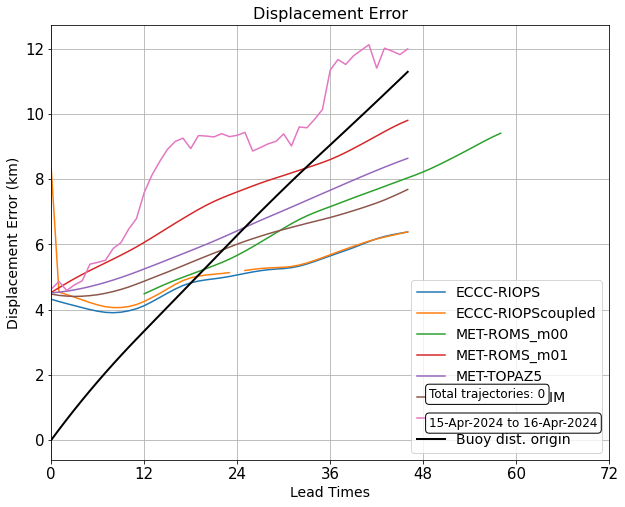

In [19]:
import matplotlib.pyplot as plt

num_valid_trajectories_all_days = []

# Loop over all samples
for daybuoy_idx in range(s1.all_displacement_errors.shape[0]):
    valid_trajectories_for_day = 0

    if not np.any(np.isnan(s1.all_displacement_errors[daybuoy_idx, :, :])):
        valid_trajectories_for_day += 1
    
    # Store the number of valid trajectories for this day
    num_valid_trajectories_all_days.append(valid_trajectories_for_day)

# Now, sum the valid trajectories across all days
total_valid_trajectories = np.sum(num_valid_trajectories_all_days)

print(f"Total valid trajectories used in the mean calculation: {total_valid_trajectories}")

times = np.arange(s1.mean_displacement_errors.shape[1])  # Assuming time corresponds to indices


# Create the figure and subplots
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Define the text to display in the box
date_range_text    = f"{s1.starttime.strftime('%d-%b-%Y')} to {s1.endtime.strftime('%d-%b-%Y')}"
trajectnumber_text = f"Total trajectories: {total_valid_trajectories}"

for mod in range(np.shape(s1.mean_displacement_errors)[0]):
    if mod!=2:
        plt.plot(times, s1.mean_displacement_errors[mod]/1000., label=str(s1.OMBdrift.model[mod].values))
    else:
        plt.plot(times+12, s1.mean_displacement_errors[mod]/1000., label=str(s1.OMBdrift.model[mod].values))

ax.plot(times,s1.mean_buoy_distance/1000, color ='k', linewidth=2,label='Buoy dist. origin')

ax.set_xlabel('Lead Times',fontsize=14)
ax.set_ylabel('Displacement Error (km)',fontsize=14)
ax.set_title('Displacement Error',fontsize=16)
ax.set_xlim([0,24*3])

# Major ticks every 20, minor ticks every 5
major_ticks = np.arange(0, 7*12, 12)
ax.set_xticks(major_ticks)
# And a corresponding grid

ax.legend(fontsize=14)
ax.grid()
plt.xticks(fontsize = 15); plt.yticks(fontsize = 15);

# Add the text box to the overall figure
fig.text(
    0.65, 0.2, date_range_text,  # Position (x, y)
    fontsize=12, ha='left', va='top',
    bbox=dict(boxstyle='round', facecolor='white', edgecolor='black')
)
# Add the text box to the overall figure
fig.text(
    0.65, 0.25, trajectnumber_text,  # Position (x, y)
    fontsize=12, ha='left', va='top',
    bbox=dict(boxstyle='round', facecolor='white', edgecolor='black')
)
plt.savefig('DriftEval_.'+f"{startdate.strftime('%d-%b-%Y')}to{enddate.strftime('%d-%b-%Y')}"+'.png', dpi=300)
plt.show()


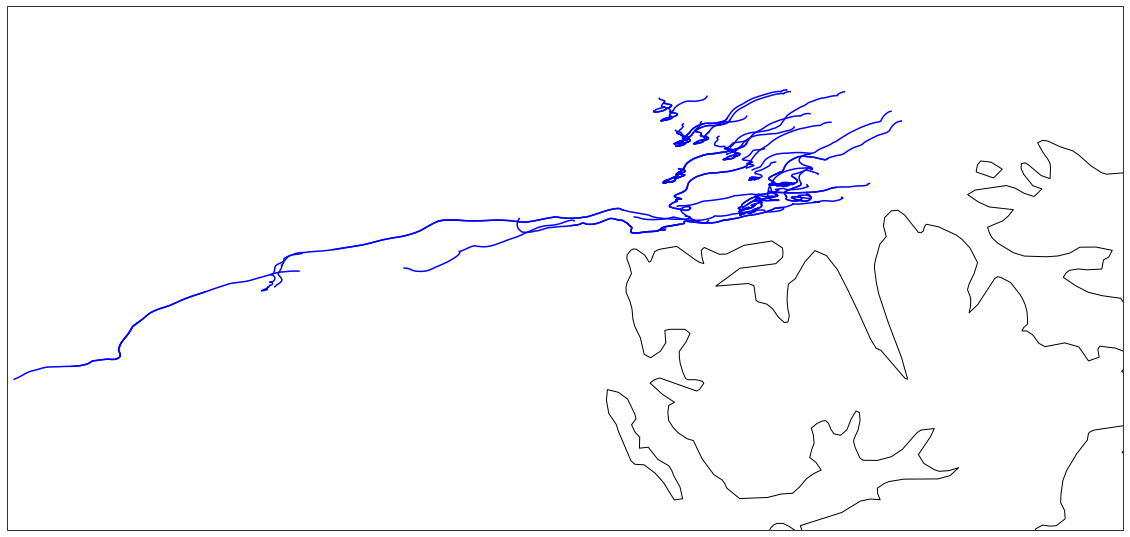

In [136]:
plot_proj = ccrs.Orthographic(14,25)

fig, ax = plt.subplots(figsize=(20, 15),nrows=1,ncols=1,
                       subplot_kw={'projection': plot_proj})

ax.coastlines(resolution='50m')

s1.all_traject_lon=np.array(s1.all_traject_lon)
s1.all_traject_lat=np.array(s1.all_traject_lat)

#ax[0].set_extent([10, 15, 80.5, 81.], crs=ccrs.PlateCarree())
ax.set_extent([0, 20, 78, 81.2], crs=ccrs.PlateCarree())

for tr in range(np.shape(s1.all_traject_lon)[0]):
    ax.plot(s1.all_traject_lon[tr,:],s1.all_traject_lat[tr,:],'b',transform = ccrs.PlateCarree())

plt.savefig('Drifter_.'+f"{startdate.strftime('%d-%b-%Y')}to{enddate.strftime('%d-%b-%Y')}"+'.png', dpi=300)
plt.show()
